Read The file and show samples

In [47]:
import pandas as pd
df=pd.read_csv("SuperMarket.csv")
df.head(5)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.22,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.048,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,NaN,10:37:00 AM,E-wallet,604.17,4.761905,30.2085,5.3


1.Display columns Name and data types

In [48]:
df.columns

Index(['Invoice ID', 'Branch', 'City', '   Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment    ', '   cogs', 'gross margin percentage',
       'gross income', 'Rating'],
      dtype='object')

In [49]:
df.dtypes

Invoice ID                  object
Branch                      object
City                        object
   Customer type            object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Sales                       object
Date                        object
Time                        object
Payment                     object
   cogs                    float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

check number of nulls for each column

In [50]:
df.isnull().sum()

Invoice ID                  0
Branch                      0
City                        0
   Customer type            0
Gender                      0
Product line                0
Unit price                 24
Quantity                    0
Tax 5%                      0
Sales                      20
Date                       12
Time                        0
Payment                     0
   cogs                     0
gross margin percentage     0
gross income                0
Rating                      0
dtype: int64

chech the numnber of duplicated row

In [51]:
df.duplicated().sum()

14

4 Display basic statistical information.

In [52]:
df.describe()

,Unit price,Quantity,Tax 5%,cogs,gross margin percentage,gross income,Rating
count,990.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000,1014.000000
mean,55.520333,5.502959,15.336872,306.737436,4.761905,15.336872,6.960454
std,26.330508,2.927133,11.685945,233.718896,0.000000,11.685945,1.721264
min,10.080000,1.000000,0.508500,10.170000,4.761905,0.508500,4.000000
25%,33.202500,3.000000,5.864625,117.292500,4.761905,5.864625,5.500000
50%,54.890000,5.000000,12.066000,241.320000,4.761905,12.066000,6.900000
75%,77.667500,8.000000,22.428000,448.560000,4.761905,22.428000,8.475000
max,99.960000,10.000000,49.650000,993.000000,4.761905,49.650000,10.000000


5 Identify any unnecessary or suspicious data

unnecessary data:
columns of -- gross margin percentage , Tax 5% , gross income , -- can be removed later 
cogs columns will be named as Cost of Goods salled

6 Observation before handling the data

1.Sales column type needs to be float
2.Date column type needs to be Datetime
3.There were 24 empty cell for unit price
4.There were 20 empty cell for Sales
5.There were 12 empty cell for Date
6.14 duplicated row needs to be removed
7.names of the columns needs to be handled

1)handling columns and data names

In [53]:
columns=df.columns
for i in columns :
    if df[i].dtype=='object' or df[i].dtype =='string':
        df[(i)]=df[(i)].str.strip()
        df[i]=df[i].str.title()
df.columns=df.columns.str.title()
df.columns=df.columns.str.strip()
df.columns=df.columns.str.replace(" ",'_')
df.rename(columns=({'Cogs':'Cost_of_Goods_saled'}),inplace=True)
df.columns


Index(['Invoice_Id', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax_5%', 'Sales', 'Date',
       'Time', 'Payment', 'Cost_of_Goods_saled', 'Gross_Margin_Percentage',
       'Gross_Income', 'Rating'],
      dtype='object')

In [54]:
df['Invoice_Id']

0       750-67-8428
1       226-31-3081
2       631-41-3108
3       123-19-1176
4       373-73-7910
           ...     
1009    886-18-2897
1010    602-16-6955
1011    745-74-0715
1012    690-01-6631
1013    652-49-6720
Name: Invoice_Id, Length: 1014, dtype: object

In [55]:
df['Invoice_Id'].value_counts()

Invoice_Id
556-41-6224    2
886-18-2897    2
588-47-8641    2
642-61-4706    2
576-31-4774    2
              ..
633-09-3463    1
374-17-3652    1
378-07-7001    1
433-75-6987    1
849-09-3807    1
Name: count, Length: 1000, dtype: int64

2)Handling the Data types

In [56]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df.dtypes

Invoice_Id                         object
Branch                             object
City                               object
Customer_Type                      object
Gender                             object
Product_Line                       object
Unit_Price                        float64
Quantity                            int64
Tax_5%                            float64
Sales                              object
Date                       datetime64[ns]
Time                               object
Payment                            object
Cost_of_Goods_saled               float64
Gross_Margin_Percentage           float64
Gross_Income                      float64
Rating                            float64
dtype: object

In [57]:
df['Payment']=df['Payment'].str.replace("Ewallet","E-Wallet")

In [58]:
df['Sales']=df['Sales'].str.replace("Egp","")


In [59]:
df['Sales']=df['Sales'].astype("float")
df.dtypes


Invoice_Id                         object
Branch                             object
City                               object
Customer_Type                      object
Gender                             object
Product_Line                       object
Unit_Price                        float64
Quantity                            int64
Tax_5%                            float64
Sales                             float64
Date                       datetime64[ns]
Time                               object
Payment                            object
Cost_of_Goods_saled               float64
Gross_Margin_Percentage           float64
Gross_Income                      float64
Rating                            float64
dtype: object

In [60]:
coordinates = df[df == "94.2375EGP"].stack().index.tolist()
print(coordinates)

[]


handling the missing values

In [61]:
df.isnull().sum()

Invoice_Id                  0
Branch                      0
City                        0
Customer_Type               0
Gender                      0
Product_Line                0
Unit_Price                 24
Quantity                    0
Tax_5%                      0
Sales                      20
Date                       12
Time                        0
Payment                     0
Cost_of_Goods_saled         0
Gross_Margin_Percentage     0
Gross_Income                0
Rating                      0
dtype: int64

In [62]:
df.columns

Index(['Invoice_Id', 'Branch', 'City', 'Customer_Type', 'Gender',
       'Product_Line', 'Unit_Price', 'Quantity', 'Tax_5%', 'Sales', 'Date',
       'Time', 'Payment', 'Cost_of_Goods_saled', 'Gross_Margin_Percentage',
       'Gross_Income', 'Rating'],
      dtype='object')

In [63]:
df[df['Unit_Price'].isnull() & df["Sales"].isnull()]

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax_5%,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Margin_Percentage,Gross_Income,Rating


In [64]:
df["Unit_Price"].isnull().sum()
df["Unit_Price"]=df["Unit_Price"].fillna((df["Sales"] - df["Tax_5%"]) / (df["Quantity"]))


In [65]:
df['Sales'].isnull().sum()

20

In [66]:
df['Sales']=df['Sales'].fillna((df["Unit_Price"] + df["Tax_5%"]) * (df["Quantity"]))

In [67]:
df['Sales'].isnull().sum()

0

In [68]:
df[df['Date'].isnull()]

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Tax_5%,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Margin_Percentage,Gross_Income,Rating
4,373-73-7910,Alex,Yangon,Member,Female,Sports And Travel,86.31,7,30.2085,634.3785,NaT,10:37:00 Am,E-Wallet,604.17,4.761905,30.2085,5.3
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic Accessories,85.39,7,29.8865,627.6165,NaT,6:30:00 Pm,E-Wallet,597.73,4.761905,29.8865,4.1
6,355-53-5943,Alex,Yangon,Member,Female,Electronic Accessories,68.84,6,20.6520,433.6920,NaT,2:36:00 Pm,E-Wallet,413.04,4.761905,20.6520,5.8
7,315-22-5665,Giza,Naypyitaw,Member,Female,Home And Lifestyle,73.56,10,36.7800,772.3800,NaT,11:38:00 Am,E-Wallet,735.60,4.761905,36.7800,8.0
8,665-32-9167,Alex,Yangon,Member,Female,Health And Beauty,36.26,2,3.6260,76.1460,NaT,5:15:00 Pm,Credit Card,72.52,4.761905,3.6260,7.2
9,692-92-5582,Cairo,Mandalay,Member,Female,Food And Beverages,54.84,3,8.2260,172.7460,NaT,1:27:00 Pm,Credit Card,164.52,4.761905,8.2260,5.9
10,351-62-0822,Cairo,Mandalay,Member,Female,Fashion Accessories,14.48,4,2.8960,60.8160,NaT,6:07:00 Pm,E-Wallet,57.92,4.761905,2.8960,4.5
11,529-56-3974,Cairo,Mandalay,Member,Female,Electronic Accessories,25.51,4,5.1020,107.1420,NaT,5:03:00 Pm,Cash,102.04,4.761905,5.1020,6.8
12,365-64-0515,Alex,Yangon,Member,Female,Electronic Accessories,46.95,5,11.7375,246.4875,NaT,10:25:00 Am,E-Wallet,234.75,4.761905,11.7375,7.1
13,252-56-2699,Alex,Yangon,Member,Female,Food And Beverages,43.19,10,21.5950,453.4950,NaT,4:48:00 Pm,E-Wallet,431.90,4.761905,21.5950,8.2


In [69]:
df.shape

(1014, 17)

remove dupicataed rows

In [70]:
df=df.drop_duplicates()

remove unnecessary columns

In [71]:
df.drop('Tax_5%', axis=1, inplace=True)
df.drop('Gross_Margin_Percentage', axis=1, inplace=True)

Adding new columns

In [72]:
df['Day']=df['Date'].dt.day_name()
df['Month']=df['Date'].dt.month_name()
df['Year']=df['Date'].dt.year
df

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Income,Rating,Day,Month,Year
0,750-67-8428,Alex,Yangon,Member,Female,Health And Beauty,74.69,7,548.9715,2019-01-05,1:08:00 Pm,E-Wallet,522.83,26.1415,9.1,Saturday,January,2019.0
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic Accessories,15.28,5,80.2200,2019-03-08,10:29:00 Am,Cash,76.40,3.8200,9.6,Friday,March,2019.0
2,631-41-3108,Alex,Yangon,Normal,Female,Home And Lifestyle,46.33,7,340.5255,2019-03-03,1:23:00 Pm,Credit Card,324.31,16.2155,7.4,Sunday,March,2019.0
3,123-19-1176,Alex,Yangon,Member,Female,Health And Beauty,58.22,8,489.0480,2019-01-27,8:33:00 Pm,E-Wallet,465.76,23.2880,8.4,Sunday,January,2019.0
4,373-73-7910,Alex,Yangon,Member,Female,Sports And Travel,86.31,7,634.3785,NaT,10:37:00 Am,E-Wallet,604.17,30.2085,5.3,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health And Beauty,40.35,1,42.3675,2019-01-29,1:46:00 Pm,E-Wallet,40.35,2.0175,6.2,Tuesday,January,2019.0
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home And Lifestyle,97.38,10,1022.4900,2019-03-02,5:16:00 Pm,E-Wallet,973.80,48.6900,4.4,Saturday,March,2019.0
997,727-02-1313,Alex,Yangon,Member,Male,Food And Beverages,31.84,1,33.4320,2019-02-09,1:22:00 Pm,Cash,31.84,1.5920,7.7,Saturday,February,2019.0
998,347-56-2442,Alex,Yangon,Normal,Male,Home And Lifestyle,65.82,1,69.1110,2019-02-22,3:33:00 Pm,Cash,65.82,3.2910,4.1,Friday,February,2019.0


In [73]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Year'] = df['Year'].fillna(2019)
df['Year'] = df['Year'].astype(int).astype(str)
df['Date'] = df['Date'].dt.date
df

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Income,Rating,Day,Month,Year
0,750-67-8428,Alex,Yangon,Member,Female,Health And Beauty,74.69,7,548.9715,2019-01-05,1:08:00 Pm,E-Wallet,522.83,26.1415,9.1,Saturday,January,2019
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic Accessories,15.28,5,80.2200,2019-03-08,10:29:00 Am,Cash,76.40,3.8200,9.6,Friday,March,2019
2,631-41-3108,Alex,Yangon,Normal,Female,Home And Lifestyle,46.33,7,340.5255,2019-03-03,1:23:00 Pm,Credit Card,324.31,16.2155,7.4,Sunday,March,2019
3,123-19-1176,Alex,Yangon,Member,Female,Health And Beauty,58.22,8,489.0480,2019-01-27,8:33:00 Pm,E-Wallet,465.76,23.2880,8.4,Sunday,January,2019
4,373-73-7910,Alex,Yangon,Member,Female,Sports And Travel,86.31,7,634.3785,NaT,10:37:00 Am,E-Wallet,604.17,30.2085,5.3,NaN,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health And Beauty,40.35,1,42.3675,2019-01-29,1:46:00 Pm,E-Wallet,40.35,2.0175,6.2,Tuesday,January,2019
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home And Lifestyle,97.38,10,1022.4900,2019-03-02,5:16:00 Pm,E-Wallet,973.80,48.6900,4.4,Saturday,March,2019
997,727-02-1313,Alex,Yangon,Member,Male,Food And Beverages,31.84,1,33.4320,2019-02-09,1:22:00 Pm,Cash,31.84,1.5920,7.7,Saturday,February,2019
998,347-56-2442,Alex,Yangon,Normal,Male,Home And Lifestyle,65.82,1,69.1110,2019-02-22,3:33:00 Pm,Cash,65.82,3.2910,4.1,Friday,February,2019


In [74]:
df

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Income,Rating,Day,Month,Year
0,750-67-8428,Alex,Yangon,Member,Female,Health And Beauty,74.69,7,548.9715,2019-01-05,1:08:00 Pm,E-Wallet,522.83,26.1415,9.1,Saturday,January,2019
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic Accessories,15.28,5,80.2200,2019-03-08,10:29:00 Am,Cash,76.40,3.8200,9.6,Friday,March,2019
2,631-41-3108,Alex,Yangon,Normal,Female,Home And Lifestyle,46.33,7,340.5255,2019-03-03,1:23:00 Pm,Credit Card,324.31,16.2155,7.4,Sunday,March,2019
3,123-19-1176,Alex,Yangon,Member,Female,Health And Beauty,58.22,8,489.0480,2019-01-27,8:33:00 Pm,E-Wallet,465.76,23.2880,8.4,Sunday,January,2019
4,373-73-7910,Alex,Yangon,Member,Female,Sports And Travel,86.31,7,634.3785,NaT,10:37:00 Am,E-Wallet,604.17,30.2085,5.3,NaN,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,233-67-5758,Giza,Naypyitaw,Normal,Male,Health And Beauty,40.35,1,42.3675,2019-01-29,1:46:00 Pm,E-Wallet,40.35,2.0175,6.2,Tuesday,January,2019
996,303-96-2227,Cairo,Mandalay,Normal,Female,Home And Lifestyle,97.38,10,1022.4900,2019-03-02,5:16:00 Pm,E-Wallet,973.80,48.6900,4.4,Saturday,March,2019
997,727-02-1313,Alex,Yangon,Member,Male,Food And Beverages,31.84,1,33.4320,2019-02-09,1:22:00 Pm,Cash,31.84,1.5920,7.7,Saturday,February,2019
998,347-56-2442,Alex,Yangon,Normal,Male,Home And Lifestyle,65.82,1,69.1110,2019-02-22,3:33:00 Pm,Cash,65.82,3.2910,4.1,Friday,February,2019


In [75]:
df.sort_values(['Date','Time'],inplace=True)
df

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Income,Rating,Day,Month,Year
17,765-26-6951,Alex,Yangon,Member,Female,Sports And Travel,72.61,6,457.4430,2019-01-01,10:39:00 Am,Credit Card,435.66,21.7830,6.9,Tuesday,January,2019
970,746-04-1077,Cairo,Mandalay,Member,Female,Food And Beverages,84.63,10,888.6150,2019-01-01,11:36:00 Am,Credit Card,846.30,42.3150,9.0,Tuesday,January,2019
839,271-77-8740,Giza,Naypyitaw,Member,Female,Sports And Travel,29.22,6,184.0860,2019-01-01,11:40:00 Am,E-Wallet,175.32,8.7660,5.0,Tuesday,January,2019
523,133-14-7229,Giza,Naypyitaw,Normal,Male,Health And Beauty,62.87,2,132.0270,2019-01-01,11:43:00 Am,Cash,125.74,6.2870,5.0,Tuesday,January,2019
567,651-88-7328,Alex,Yangon,Normal,Female,Fashion Accessories,65.74,9,621.2430,2019-01-01,1:55:00 Pm,Cash,591.66,29.5830,7.7,Tuesday,January,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,529-56-3974,Cairo,Mandalay,Member,Female,Electronic Accessories,25.51,4,107.1420,NaT,5:03:00 Pm,Cash,102.04,5.1020,6.8,NaN,NaN,2019
8,665-32-9167,Alex,Yangon,Member,Female,Health And Beauty,36.26,2,76.1460,NaT,5:15:00 Pm,Credit Card,72.52,3.6260,7.2,NaN,NaN,2019
10,351-62-0822,Cairo,Mandalay,Member,Female,Fashion Accessories,14.48,4,60.8160,NaT,6:07:00 Pm,E-Wallet,57.92,2.8960,4.5,NaN,NaN,2019
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic Accessories,85.39,7,627.6165,NaT,6:30:00 Pm,E-Wallet,597.73,29.8865,4.1,NaN,NaN,2019


In [76]:
df['Satisfaction']=df['Rating'].apply(lambda Rating : "Satisfied" if Rating >=7 else "not Satisfied")

In [77]:
df

,Invoice_Id,Branch,City,Customer_Type,Gender,Product_Line,Unit_Price,Quantity,Sales,Date,Time,Payment,Cost_of_Goods_saled,Gross_Income,Rating,Day,Month,Year,Satisfaction
17,765-26-6951,Alex,Yangon,Member,Female,Sports And Travel,72.61,6,457.4430,2019-01-01,10:39:00 Am,Credit Card,435.66,21.7830,6.9,Tuesday,January,2019,not Satisfied
970,746-04-1077,Cairo,Mandalay,Member,Female,Food And Beverages,84.63,10,888.6150,2019-01-01,11:36:00 Am,Credit Card,846.30,42.3150,9.0,Tuesday,January,2019,Satisfied
839,271-77-8740,Giza,Naypyitaw,Member,Female,Sports And Travel,29.22,6,184.0860,2019-01-01,11:40:00 Am,E-Wallet,175.32,8.7660,5.0,Tuesday,January,2019,not Satisfied
523,133-14-7229,Giza,Naypyitaw,Normal,Male,Health And Beauty,62.87,2,132.0270,2019-01-01,11:43:00 Am,Cash,125.74,6.2870,5.0,Tuesday,January,2019,not Satisfied
567,651-88-7328,Alex,Yangon,Normal,Female,Fashion Accessories,65.74,9,621.2430,2019-01-01,1:55:00 Pm,Cash,591.66,29.5830,7.7,Tuesday,January,2019,Satisfied
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11,529-56-3974,Cairo,Mandalay,Member,Female,Electronic Accessories,25.51,4,107.1420,NaT,5:03:00 Pm,Cash,102.04,5.1020,6.8,NaN,NaN,2019,not Satisfied
8,665-32-9167,Alex,Yangon,Member,Female,Health And Beauty,36.26,2,76.1460,NaT,5:15:00 Pm,Credit Card,72.52,3.6260,7.2,NaN,NaN,2019,Satisfied
10,351-62-0822,Cairo,Mandalay,Member,Female,Fashion Accessories,14.48,4,60.8160,NaT,6:07:00 Pm,E-Wallet,57.92,2.8960,4.5,NaN,NaN,2019,not Satisfied
5,699-14-3026,Giza,Naypyitaw,Member,Female,Electronic Accessories,85.39,7,627.6165,NaT,6:30:00 Pm,E-Wallet,597.73,29.8865,4.1,NaN,NaN,2019,not Satisfied


Answer the Quesiton

1)total revenue

In [78]:
total_revenue=df['Sales'].sum()
print(f"total revenue is : {total_revenue:.2f} EGP")


total revenue is : 325895.23 EGP


2)cities' revenues and most one

In [79]:
total_revenue_by_city=df.groupby("City")['Sales'].sum()
print(f'city revenue \n{total_revenue_by_city}')
total_city_revenue = str(total_revenue_by_city.max() )
total_city_revenue_name = str(total_revenue_by_city.idxmax()) 
print(f'Best selling city is : {total_city_revenue_name} with revenue of {total_city_revenue} EGP')

city revenue 
City
Mandalay     106602.3390
Naypyitaw    111745.7945
Yangon       107547.0965
Name: Sales, dtype: float64
Best selling city is : Naypyitaw with revenue of 111745.7945 EGP


In [80]:
total_profit_by_branch=df.groupby("Branch")['Gross_Income'].sum()
print(f'Branch profit \n{total_profit_by_branch}')
total_brach_profit = str(total_profit_by_branch.max() )
total_Branch_profit_name = str(total_profit_by_branch.idxmax()) 
print(f'Best selling Branch is : {total_Branch_profit_name} with profit of {total_brach_profit} EGP')

Branch profit 
Branch
Alex     5057.1605
Cairo    5057.0320
Giza     5265.1765
Name: Gross_Income, dtype: float64
Best selling Branch is : Giza with profit of 5265.1765 EGP


In [92]:
total_revenue_by_product_category=df.groupby("Product_Line")['Sales'].sum()
print(f'Product          |          revenue\n{total_revenue_by_product_category}')
total_Product_revenue = str(total_revenue_by_product_category.max() )
total_Product_revenue_name = str(total_revenue_by_product_category.idxmax()) 
print("==============")
total_profit_by_product_category=df.groupby("Product_Line")['Gross_Income'].sum()
print(f'Product profit\n{total_profit_by_product_category}')
total_product_profit = str(total_profit_by_product_category.max() )
total_product_profit_name = str(total_profit_by_product_category.idxmax()) 
print(f'Best profit Product Line is : {total_product_profit_name} with profit of {total_product_profit} EGP')
print(f'Best revenue Product Line is : {total_Product_revenue_name} with profit of {total_Product_revenue} EGP')

Product          |          revenue
Product_Line
Electronic Accessories    54738.0555
Fashion Accessories       54731.8500
Food And Beverages        56562.0600
Health And Beauty         49564.8250
Home And Lifestyle        54544.3290
Sports And Travel         55754.1105
Name: Sales, dtype: float64
Product profit
Product_Line
Electronic Accessories    2587.5015
Fashion Accessories       2585.9950
Food And Beverages        2673.5640
Health And Beauty         2342.5590
Home And Lifestyle        2564.8530
Sports And Travel         2624.8965
Name: Gross_Income, dtype: float64
Best profit Product Line is : Food And Beverages with profit of 2673.564 EGP
Best revenue Product Line is : Food And Beverages with profit of 56562.06 EGP


In [82]:
total_spend_customer_type=df.groupby("Customer_Type")['Sales'].sum()
print(f'Product revenue\n{total_spend_customer_type}')
cutomer_spend_more = str(total_spend_customer_type.max() )
total_cutomer_spend_more_name = str(total_spend_customer_type.idxmax()) 
print(f'customer spend more is : {total_cutomer_spend_more_name} with total spend: {cutomer_spend_more} EGP')

Product revenue
Customer_Type
Member    192623.245
Normal    133271.985
Name: Sales, dtype: float64
customer spend more is : Member with total spend: 192623.245 EGP


In [83]:
payment_method=df['Payment'].value_counts()
print(payment_method)
most_method=df['Payment'].max()
most_method_amount=payment_method.max()

print(f"most popular method used is : {most_method} with {most_method_amount} processes")


Payment
E-Wallet       345
Cash           344
Credit Card    311
Name: count, dtype: int64
most popular method used is : E-Wallet with 345 processes


In [84]:
average= df['Sales'].mean()
print(f"The average transaction value is: {average:.2f} EGP")

The average transaction value is: 325.90 EGP


In [85]:
customer_Branch=df['Branch'].value_counts()
print(customer_Branch)
cutomer_satisfy=df.groupby("Branch")["Satisfaction"].value_counts()
satisfied_customer=(df[df['Satisfaction']=='Satisfied'])["Branch"].value_counts()
print(satisfied_customer)
sat_percentage=satisfied_customer/customer_Branch *100
print(f'percentage of satisfaction for each branch is : \n{sat_percentage} ')
max_sat=(satisfied_customer/customer_Branch).idxmax()
print(f"Branch with most percent of satisfication is : {max_sat}")

Branch
Alex     340
Cairo    332
Giza     328
Name: count, dtype: int64
Branch
Alex     179
Giza     171
Cairo    151
Name: count, dtype: int64
percentage of satisfaction for each branch is : 
Branch
Alex     52.647059
Cairo    45.481928
Giza     52.134146
Name: count, dtype: float64 
Branch with most percent of satisfication is : Alex


In [86]:
total_revenue_by_day =df.groupby("Day")['Sales'].sum()
total_revenue_by_month =df.groupby("Month")['Sales'].sum()
highest_sales_day =total_revenue_by_day.max()
highest_sales_day_name =total_revenue_by_day.idxmax()
highest_sales_month =total_revenue_by_month.max()
highest_sales_month_name =total_revenue_by_month.idxmax()
print(total_revenue_by_day)
print(total_revenue_by_month) 
print(f'highest_sales_day is  {highest_sales_day_name} with revenue of {highest_sales_day}') 
print(f'highest_sales_month is  {highest_sales_month_name} with revenue of {highest_sales_month}') 


Day
Friday       42549.8940
Monday       37263.7245
Saturday     56127.5325
Sunday       44698.9415
Thursday     45711.1400
Tuesday      50974.6050
Wednesday    43644.5670
Name: Sales, dtype: float64
Month
February     95554.6030
January     117123.2130
March       108292.5885
Name: Sales, dtype: float64
highest_sales_day is  Saturday with revenue of 56127.5325
highest_sales_month is  January with revenue of 117123.213


In [87]:
over_all_customer=df['Branch'].count()
over_all_satisfied=(df['Satisfaction']=='Satisfied').sum()/over_all_customer
over_all_satisfied_percentage=over_all_satisfied *100
print(f"over_all_satisfied percentage is {over_all_satisfied_percentage} %")

over_all_satisfied percentage is 50.1 %


In [88]:
df.to_csv("SuperMarket_modified.csv" ,index=False)

C:\Users\mohamed\AppData\Local\Temp\ipykernel_3736\86837365.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_revenue_by_city.index, y=total_revenue_by_city.values, ax=ax1, palette="cool")
C:\Users\mohamed\AppData\Local\Temp\ipykernel_3736\86837365.py:94: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=total_profit_by_branch.index, y=total_profit_by_branch.values, ax=ax2, palette="spring")
C:\Users\mohamed\AppData\Local\Temp\ipykernel_3736\86837365.py:102: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sat_percentage.index, y=sat

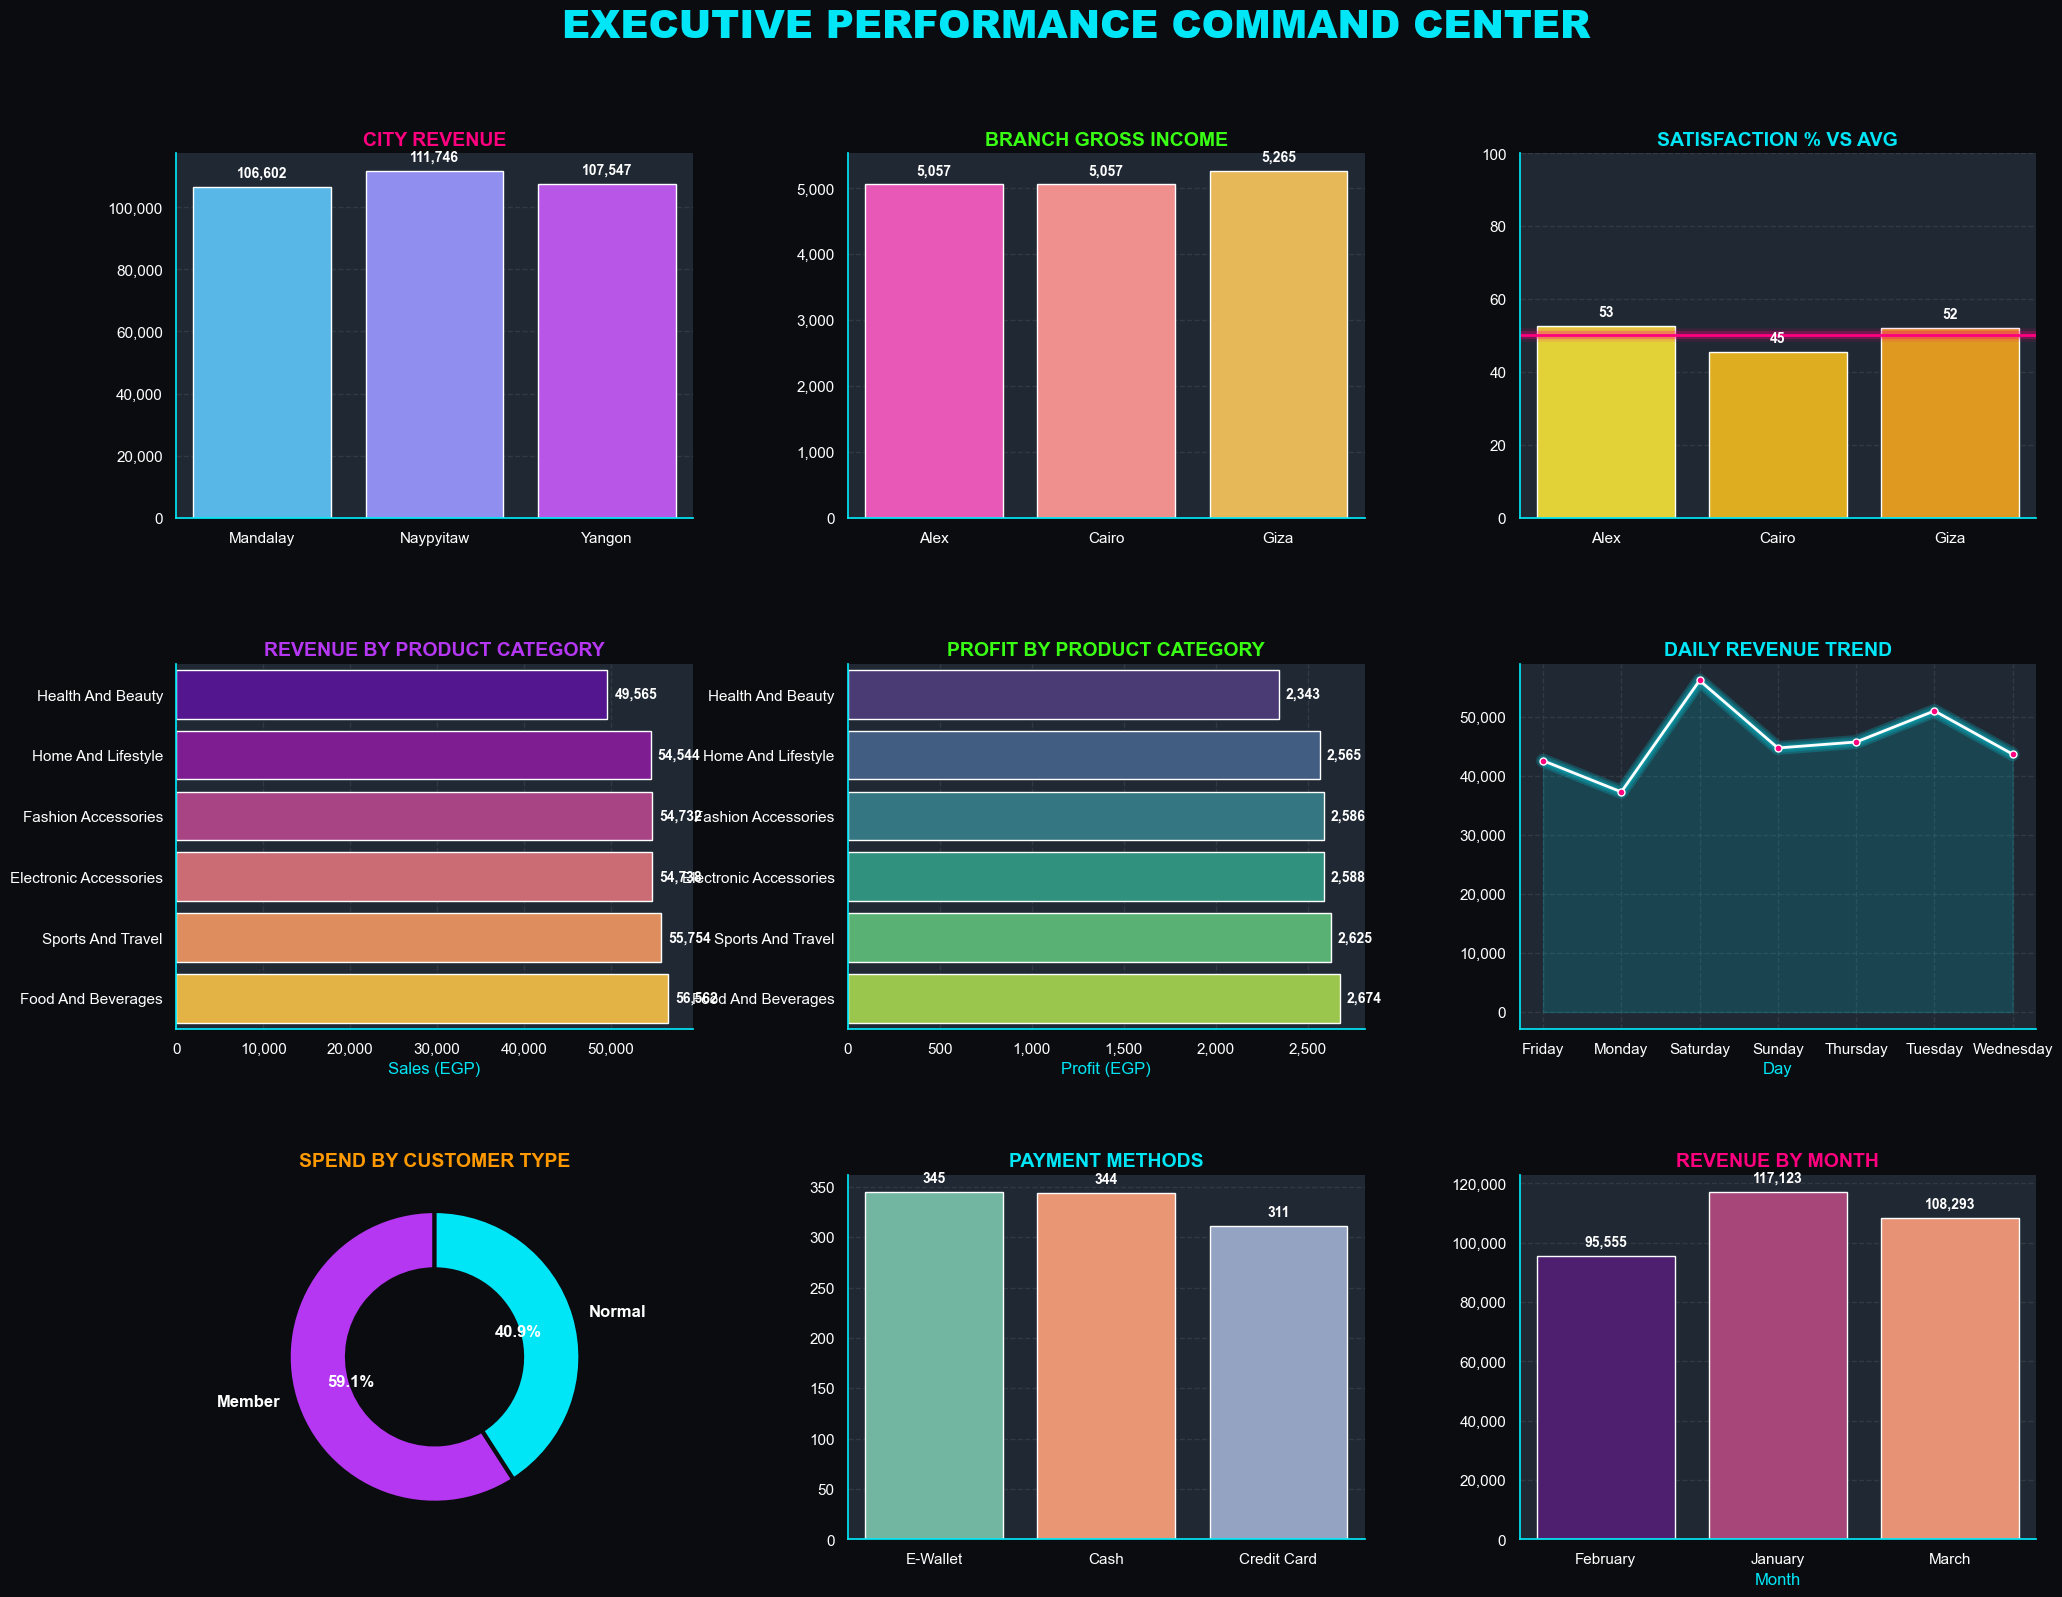

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# ==========================================
# 0. The "Ultra-Fancy" Dark Mode Setup
# ==========================================
plt.style.use('dark_background')

# Define a neon color palette
neon_blue = '#00e6F6'
neon_pink = '#ff007f'
neon_green = '#39ff14'
neon_purple = '#b537f2'
neon_orange = '#ff9900'
bg_color = '#0b0c10'
panel_color = '#1f2833'

# Configure custom RC parameters
sns.set_theme(
    style="dark",
    rc={
        "figure.facecolor": bg_color,
        "axes.facecolor": panel_color,
        "axes.edgecolor": neon_blue,
        "axes.grid": True,
        "grid.color": '#454a52',
        "grid.linestyle": '--',
        "grid.alpha": 0.5,
        "text.color": 'white',
        "axes.labelcolor": neon_blue,
        "xtick.color": 'white',
        "ytick.color": 'white',
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

def currency_format(x, pos):
    return f"{x:,.0f}"
formatter = FuncFormatter(currency_format)

def neon_bar_labels(ax, is_horizontal=False):
    for p in ax.patches:
        if is_horizontal:
            ax.annotate(f'{p.get_width():,.0f}', 
                        (p.get_width(), p.get_y() + p.get_height() / 2.), 
                        ha='left', va='center', fontsize=10, fontweight='bold', color='white',
                        xytext=(5, 0), textcoords='offset points')
        else:
            ax.annotate(f'{p.get_height():,.0f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=10, fontweight='bold', color='white',
                        xytext=(0, 5), textcoords='offset points')

# ==========================================
# 1. Build the 3x3 Dashboard Layout
# ==========================================
fig = plt.figure(figsize=(24, 18))
fig.patch.set_facecolor(bg_color)
fig.suptitle('EXECUTIVE PERFORMANCE COMMAND CENTER', color=neon_blue, fontsize=28, fontweight='heavy', y=0.96)

# Create a 3x3 Grid
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# --- ROW 1 ---
ax1 = fig.add_subplot(gs[0, 0]) # City Revenue
ax2 = fig.add_subplot(gs[0, 1]) # Branch Profit
ax3 = fig.add_subplot(gs[0, 2]) # Customer Satisfaction

# --- ROW 2 ---
ax4 = fig.add_subplot(gs[1, 0]) # Product Revenue
ax5 = fig.add_subplot(gs[1, 1]) # Product Profit
ax6 = fig.add_subplot(gs[1, 2]) # Daily Sales Trend

# --- ROW 3 ---
ax7 = fig.add_subplot(gs[2, 0]) # Customer Type Donut
ax8 = fig.add_subplot(gs[2, 1]) # Payment Methods
ax9 = fig.add_subplot(gs[2, 2]) # Monthly Revenue

# ==========================================
# 2. Populate the Charts
# ==========================================

# ROW 1, COL 1: City Revenue
sns.barplot(x=total_revenue_by_city.index, y=total_revenue_by_city.values, ax=ax1, palette="cool")
ax1.set_title('CITY REVENUE', color=neon_pink, fontsize=14, fontweight='bold')
ax1.yaxis.set_major_formatter(formatter)
ax1.set_ylabel('')
ax1.set_xlabel('')
neon_bar_labels(ax1)

# ROW 1, COL 2: Branch Profit
sns.barplot(x=total_profit_by_branch.index, y=total_profit_by_branch.values, ax=ax2, palette="spring")
ax2.set_title('BRANCH GROSS INCOME', color=neon_green, fontsize=14, fontweight='bold')
ax2.yaxis.set_major_formatter(formatter)
ax2.set_ylabel('')
ax2.set_xlabel('')
neon_bar_labels(ax2)

# ROW 1, COL 3: Satisfaction Level
sns.barplot(x=sat_percentage.index, y=sat_percentage.values, ax=ax3, palette="Wistia")
# Adding a "glow" to the line
for alpha, lw in zip([0.1, 0.3, 1.0], [10, 6, 2]):
    ax3.axhline(y=over_all_satisfied_percentage, color=neon_pink, linestyle='-', linewidth=lw, alpha=alpha)
ax3.set_title('SATISFACTION % VS AVG', color=neon_blue, fontsize=14, fontweight='bold')
ax3.set_ylim(0, 100)
ax3.set_ylabel('')
ax3.set_xlabel('')
neon_bar_labels(ax3)

# ROW 2, COL 1: Product Revenue
revenue_sorted = total_revenue_by_product_category.sort_values(ascending=True) # Ascending for horizontal
sns.barplot(y=revenue_sorted.index, x=revenue_sorted.values, ax=ax4, palette="plasma")
ax4.set_title('REVENUE BY PRODUCT CATEGORY', color=neon_purple, fontsize=14, fontweight='bold')
ax4.xaxis.set_major_formatter(formatter)
ax4.set_ylabel('')
ax4.set_xlabel('Sales (EGP)')
neon_bar_labels(ax4, is_horizontal=True)

# ROW 2, COL 2: Product Profit
profit_sorted = total_profit_by_product_category.sort_values(ascending=True)
sns.barplot(y=profit_sorted.index, x=profit_sorted.values, ax=ax5, palette="viridis")
ax5.set_title('PROFIT BY PRODUCT CATEGORY', color=neon_green, fontsize=14, fontweight='bold')
ax5.xaxis.set_major_formatter(formatter)
ax5.set_ylabel('')
ax5.set_xlabel('Profit (EGP)')
neon_bar_labels(ax5, is_horizontal=True)

# ROW 2, COL 3: Daily Sales Trend
x_days = total_revenue_by_day.index
y_sales = total_revenue_by_day.values
# Glowing line effect
for lw in [10, 7, 4]:
    ax6.plot(x_days, y_sales, color=neon_blue, alpha=0.2, linewidth=lw)
ax6.plot(x_days, y_sales, color='white', linewidth=2, marker='o', markersize=5, markerfacecolor=neon_pink)
ax6.fill_between(x_days, y_sales, color=neon_blue, alpha=0.15)
ax6.set_title('DAILY REVENUE TREND', color=neon_blue, fontsize=14, fontweight='bold')
ax6.yaxis.set_major_formatter(formatter)
ax6.set_ylabel('')
ax6.set_xlabel('Day')

# ROW 3, COL 1: Customer Type Donut
colors = [neon_purple, neon_blue]
ax7.pie(
    total_spend_customer_type.values, 
    labels=total_spend_customer_type.index, 
    autopct='%1.1f%%', 
    colors=colors, 
    startangle=90, 
    wedgeprops=dict(width=0.4, edgecolor=bg_color, linewidth=3), # Dark edges to match background
    textprops=dict(fontsize=12, fontweight='bold', color='white')
)
ax7.set_title('SPEND BY CUSTOMER TYPE', color=neon_orange, fontsize=14, fontweight='bold')

# ROW 3, COL 2: Payment Methods
sns.countplot(data=df, x='Payment', ax=ax8, palette="Set2", order=df['Payment'].value_counts().index)
ax8.set_title('PAYMENT METHODS', color=neon_blue, fontsize=14, fontweight='bold')
ax8.set_ylabel('')
ax8.set_xlabel('')
neon_bar_labels(ax8)

# ROW 3, COL 3: Monthly Revenue
sns.barplot(x=total_revenue_by_month.index, y=total_revenue_by_month.values, ax=ax9, palette="magma")
ax9.set_title('REVENUE BY MONTH', color=neon_pink, fontsize=14, fontweight='bold')
ax9.yaxis.set_major_formatter(formatter)
ax9.set_ylabel('')
ax9.set_xlabel('Month')
neon_bar_labels(ax9)
plt.savefig("dashboard.png", bbox_inches='tight')
plt.show()